In [1]:
!hostname

gl1505.arc-ts.umich.edu


In [2]:
from pathlib import Path

# ====== 경로 설정 ======
ROOT = Path("/scratch/jjparkcv_root/jjparkcv98/minsukc/LIDC")
DICOM_ROOT = ROOT / "LIDC-IDRI_Data"      # DICOM 폴더
NIFTI_ROOT = ROOT / "LIDC_NII_Data"     # 출력 폴더

## DICOM -> NII 변환

In [3]:
import SimpleITK as sitk
from tqdm import tqdm

In [4]:
NIFTI_ROOT.mkdir(exist_ok=True)

def dicom_series_to_nifti(dicom_dir: Path, out_path: Path):
    reader = sitk.ImageSeriesReader()
    series_ids = reader.GetGDCMSeriesIDs(str(dicom_dir))

    if not series_ids:
        print(f"[SKIP] No DICOM series in {dicom_dir}")
        return

    # LIDC는 보통 series 하나
    series_id = series_ids[0]
    dicom_files = reader.GetGDCMSeriesFileNames(
        str(dicom_dir), series_id
    )

    reader.SetFileNames(dicom_files)
    image = reader.Execute()

    sitk.WriteImage(image, str(out_path))

In [5]:
# patients = sorted([p for p in DICOM_ROOT.iterdir() if p.is_dir()])

# for idx, patient_dir in enumerate(
#     tqdm(patients, desc="Converting DICOM → NIfTI")
# ):
    
#     short_id = f"LIDC_{idx:04d}"
#     out_file = NIFTI_ROOT / f"{short_id}.nii.gz"

#     if out_file.exists():
#         print("file exists. skipping...")
#         continue

#     try:
#         dicom_series_to_nifti(patient_dir, out_file)
#     except Exception as e:
#         print(f"[ERROR] {patient_dir.name}: {e}")

## 데이터 분석

#### Function Definition

In [6]:
import SimpleITK as sitk
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# NOTE: Only reads header info. fast.
def analyze_nifti_fast(data_dir: Path):
    print(f"[DEBUG] Starting FAST analysis in: {data_dir}") # Debug line
    files = sorted(list(data_dir.glob("*.nii.gz")))
    
    if not files:
        print("[DEBUG] No files found.")
        return

    stats = []
    reader = sitk.ImageFileReader() # NOTE: Reuse reader for speed

    for p in tqdm(files, desc="Scanning Metadata"):
        try:
            reader.SetFileName(str(p))
            # NOTE: 전체 픽셀 데이터 없이 정보만 읽기
            reader.ReadImageInformation() 
            
            size = reader.GetSize()
            spacing = reader.GetSpacing()
            
            stats.append({
                "file": p.name,
                "size_x": size[0], # NEW: x size
                "size_y": size[1], # NEW: y size
                "size_z": size[2],
                "spacing_x": round(spacing[0], 3), # NEW: x spacing
                "spacing_y": round(spacing[1], 3), # NEW: y spacing
                "spacing_z": round(spacing[2], 3),
            })
        except Exception as e:
            print(f"[ERROR] {p.name}: {e}")

    df = pd.DataFrame(stats)
    
    # Summary
    print("\n" + "="*40)
    print(" [FAST Analysis Summary (Metadata)]")
    print("="*40)
    print(f"Total Valid Files: {len(df)}")
    
    # 1. NEW: Average Shape (Size)
    avg_shape = df[["size_x", "size_y", "size_z"]].mean()
    print(f"\n1. Average Shape (X, Y, Z):")
    print(f"    {avg_shape.round(2).values}")
    
    # 2. NEW: Average Spacing
    avg_spacing = df[["spacing_x", "spacing_y", "spacing_z"]].mean()
    print(f"\n2. Average Spacing (X, Y, Z) (mm):")
    print(f"    {avg_spacing.round(3).values}")
    
    # 3. Spacing Consistency Check
    # X, Y Spacing (픽셀 크기) 일관성 확인이 중요함
    unique_spacings_xy = df.groupby(["spacing_x", "spacing_y"]).size()
    
    print(f"\n3. XY Spacing Consistency:")
    if len(unique_spacings_xy) == 1:
        print("    [SUCCESS] All files have the same XY pixel spacing!")
    else:
        print(f"    [WARNING] Found {len(unique_spacings_xy)} different XY spacing variations.")
        print(unique_spacings_xy)

    print("="*40)
    
    return df


In [7]:
import SimpleITK as sitk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# NOTE: Reads full image. Checks HU stats & Orientation.
def analyze_nifti_comprehensive(data_dir: Path):
    print(f"[DEBUG] Starting COMPREHENSIVE analysis in: {data_dir}")
    files = sorted(list(data_dir.glob("*.nii.gz")))
    
    if not files:
        print("[DEBUG] No files found.")
        return

    stats = []
    stat_filter = sitk.StatisticsImageFilter()

    for p in tqdm(files, desc="Analyzing Full Data"):
        try:
            # NOTE: ReadImage loads all pixels -> slower but necessary for HU
            img = sitk.ReadImage(str(p))
            
            # 1. Metadata
            size = img.GetSize()
            spacing = img.GetSpacing()
            direction = np.round(img.GetDirection(), 2) # Orientation matrix
            
            # 2. Pixel Statistics (HU)
            stat_filter.Execute(img)
            
            stats.append({
                "file": p.name,
                "z_slices": size[2],
                "spacing_z": round(spacing[2], 3),
                "min_hu": stat_filter.GetMinimum(),
                "max_hu": stat_filter.GetMaximum(),
                "mean_hu": stat_filter.GetMean(),
                "direction": str(direction) # Stringify for grouping
            })
        except Exception as e:
            print(f"[ERROR] Corrupt file {p.name}: {e}")

    df = pd.DataFrame(stats)

    # -----------------------------
    # Visual Report
    # -----------------------------
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Slice Depth
    sns.histplot(df['z_slices'], ax=ax[0], bins=15, kde=True)
    ax[0].set_title("Distribution of Slice Counts (Depth)")
    
    # Plot 2: HU Range (Min/Max)
    sns.histplot(df['min_hu'], color='blue', label='Min HU', ax=ax[1], kde=True)
    sns.histplot(df['max_hu'], color='red', label='Max HU', ax=ax[1], kde=True)
    ax[1].set_title("Intensity Range (HU)")
    ax[1].legend()

    # Plot 3: Z-Spacing
    sns.histplot(df['spacing_z'], color='green', ax=ax[2], kde=False)
    ax[2].set_title("Z-Spacing (Slice Thickness)")
    
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Text Summary
    # -----------------------------
    print("\n" + "="*40)
    print(" [Comprehensive Report]")
    print("="*40)
    print(f"Avg HU Range: {df['min_hu'].mean():.1f} to {df['max_hu'].mean():.1f}")
    
    # Orientation Check (Crucial for Deep Learning)
    unique_dirs_count = df['direction'].nunique()
    print(f"2. Orientation Consistency Check:")
    if unique_dirs_count > 1:
        print(f"   [CRITICAL WARNING] Found {unique_dirs_count} different orientations!")
        print("   Model training may fail or registration can be inaccurate if directions are mixed.")
        print("\n   --- Unique Orientation Matrices Found ---")
        # NEW: 상세 출력 요청 반영
        print(df['direction'].value_counts()) 
        print("   -----------------------------------------")
    else:
        print("   [SUCCESS] Orientation is consistent across dataset.")

    return df

In [8]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import SimpleITK as sitk
import numpy as np
from pathlib import Path

ROOT = Path("/scratch/jjparkcv_root/jjparkcv98/minsukc/LIDC")
NIFTI_ROOT = ROOT / "LIDC_NII_Data" 

def view_nifti_interactive(nifti_dir: Path, file_idx: int = 0):
    files = sorted(list(nifti_dir.glob("*.nii.gz")))
    if not files:
        print("No files found.")
        return
    
    target_file = files[file_idx]
    img = sitk.ReadImage(str(target_file))
    img_arr = sitk.GetArrayFromImage(img)  # (z,y,x)

    size = img.GetSize()        # (x,y,z)
    spacing = img.GetSpacing()  # (x,y,z)

    hu_min, hu_max = float(img_arr.min()), float(img_arr.max())
    hu_mean, hu_std = float(img_arr.mean()), float(img_arr.std())

    # -------------------------
    # 출력 박스는 interact와 분리
    # -------------------------
    info_out = widgets.Output()
    with info_out:
        print("===== Image Info =====")
        print(f"File: {target_file.name}")
        print(f"Shape (z,y,x): {img_arr.shape}")
        print(f"Size (x,y,z):  {size}")
        print(f"Spacing (mm):  {spacing}")
        print(f"HU Min:  {hu_min:.2f}")
        print(f"HU Max:  {hu_max:.2f}")
        print(f"HU Mean: {hu_mean:.2f}")
        print(f"HU Std:  {hu_std:.2f}")
        print("======================")

    # -------------------------
    # 슬라이스 시각화
    # -------------------------
    def show_slice(idx):
        plt.figure(figsize=(6,6))
        plt.imshow(img_arr[idx], cmap="gray")
        plt.title(f"{target_file.name} | Slice {idx}")
        plt.axis("off")
        plt.show()

    slider = widgets.IntSlider(
        min=0, 
        max=img_arr.shape[0] - 1, 
        value=img_arr.shape[0]//2
    )

    ui = widgets.VBox([info_out, slider])
    out = widgets.interactive_output(show_slice, {"idx": slider})

    display(ui, out)

In [9]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import SimpleITK as sitk
import numpy as np
import seaborn as sns # NEW: 히스토그램 시각화용
from pathlib import Path

# =========================================================
# 경로 설정
# =========================================================
ROOT = Path("/scratch/jjparkcv_root/jjparkcv98/minsukc/LIDC")
NIFTI_ROOT = ROOT / "LIDC_NII_Data"

# HU 히스토그램의 플롯 범위를 상수로 정의 (예: 흉부 CT 범위)
HU_PLOT_RANGE = (-1024, 600) 

def view_nifti_interactive_with_slice_hist(nifti_dir: Path, file_idx: int = 0):
    files = sorted(list(nifti_dir.glob("*.nii.gz")))
    if not files:
        print("[DEBUG] No files found.")
        return
    
    target_file = files[file_idx]
    
    # NOTE: HU 값 분석과 슬라이스 보기를 위해 전체 이미지를 읽습니다.
    img = sitk.ReadImage(str(target_file))
    img_arr = sitk.GetArrayFromImage(img)  # (z,y,x)

    # ... (생략된 이미지 정보 계산) ...
    size = img.GetSize()
    spacing = img.GetSpacing()
    hu_min, hu_max = float(img_arr.min()), float(img_arr.max())
    hu_mean, hu_std = float(img_arr.mean()), float(img_arr.std())
    
    # -------------------------
    # NEW: 히스토그램과 슬라이스 영상을 동시에 출력하는 함수
    # -------------------------
    def show_slice(idx):
        # NEW: Debug line to track slice index change
        print(f"[DEBUG] Processing slice index: {idx}", end='\r') 
        
        slice_data = img_arr[idx]
        
        # NOTE: 1행 2열의 서브플롯 생성 (영상, 히스토그램)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # --- 1. 슬라이스 영상 플롯 ---
        axes[0].imshow(slice_data, cmap="gray", 
                       vmin=HU_PLOT_RANGE[0], vmax=HU_PLOT_RANGE[1]) # NEW: HU 범위로 VMin/VMax 설정
        axes[0].set_title(f"Slice {idx} | Image")
        axes[0].axis("off")
        
        # --- 2. HU 히스토그램 플롯 (해당 슬라이스만) ---
        # NOTE: 현재 슬라이스의 픽셀만 사용 (img_arr[idx].flatten())
        sns.histplot(
            slice_data.flatten(), 
            bins=100, 
            kde=True,
            stat="count",
            color='teal',
            ax=axes[1],
            binrange=HU_PLOT_RANGE 
        )
        axes[1].set_title(f"HU Distribution (Slice {idx})")
        axes[1].set_xlabel(f"HU Value (Range: {HU_PLOT_RANGE[0]} to {HU_PLOT_RANGE[1]})")
        axes[1].axvline(x=0, color='r', linestyle='--', linewidth=1)
        axes[1].grid(True, alpha=0.5)

        plt.tight_layout()
        plt.show()

    # -------------------------
    # 이미지 정보 출력 (정적)
    # -------------------------
    info_out = widgets.Output()
    with info_out:
        print("===== Image Info (Slice Hist Mode) =====")
        print(f"File: {target_file.name}")
        print(f"Shape (z,y,x): {img_arr.shape}")
        print(f"HU Mean/Std: {hu_mean:.2f} / {hu_std:.2f}")
        print(f"Plot Range: {HU_PLOT_RANGE}")
        print("========================================")

    # -------------------------
    # 슬라이더 및 인터랙티브 출력
    # -------------------------
    slider = widgets.IntSlider(
        min=0, 
        max=img_arr.shape[0] - 1, 
        value=img_arr.shape[0]//2,
        description='Slice Index' # NEW: 설명 추가
    )

    ui = widgets.VBox([info_out, slider])
    # NOTE: show_slice 함수가 업데이트된 idx 값을 받음
    out = widgets.interactive_output(show_slice, {"idx": slider}) 

    display(ui, out)

#### Analysis

[DEBUG] Starting COMPREHENSIVE analysis in: /scratch/jjparkcv_root/jjparkcv98/minsukc/LIDC/LIDC_NII_Data


Analyzing Full Data: 100%|██████████████████████████████████████████████████████| 1254/1254 [56:02<00:00,  2.68s/it]


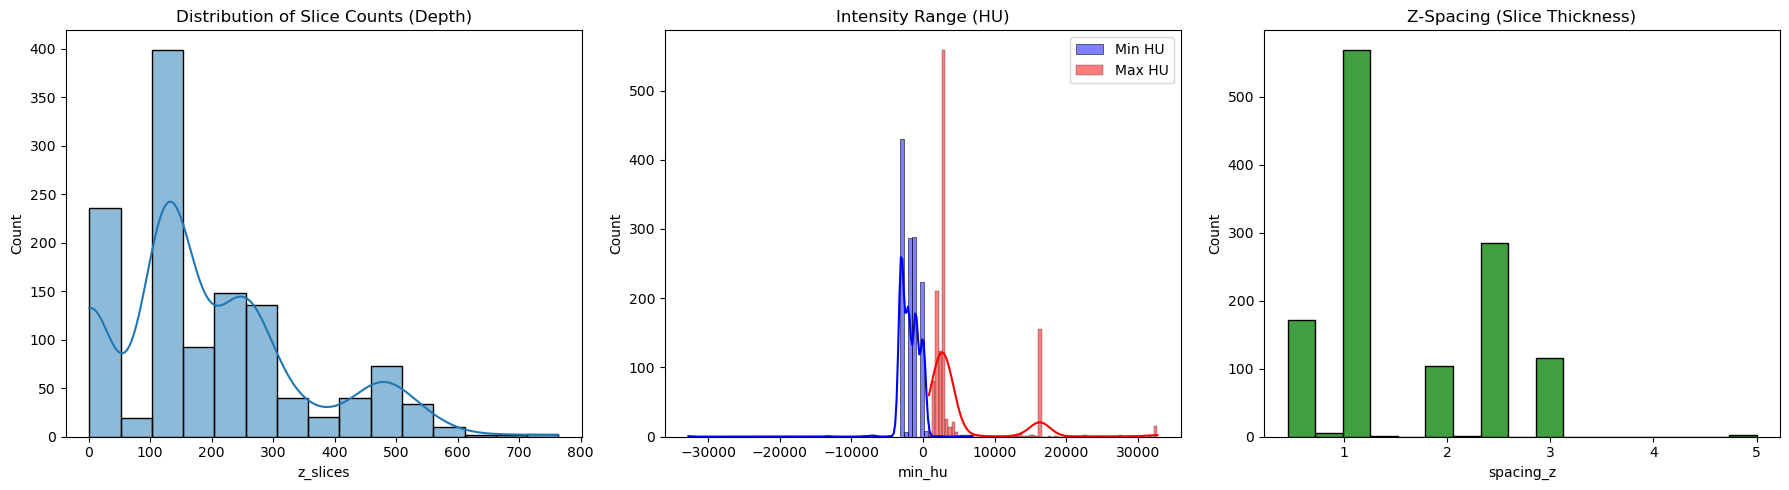


 [Comprehensive Report]
Avg HU Range: -1799.5 to 5097.7
2. Orientation Consistency Check:
   [CRITICAL WARNING] Found 2 different orientations!
   Model training may fail or registration can be inaccurate if directions are mixed.

   --- Unique Orientation Matrices Found ---
direction
[1. 0. 0. 0. 1. 0. 0. 0. 1.]             1240
[-1.  0.  0.  0. -1.  0.  0.  0.  1.]      14
Name: count, dtype: int64
   -----------------------------------------


In [10]:
# 분석 (Comprehensive)
df_comp = analyze_nifti_comprehensive(NIFTI_ROOT)

In [11]:
# 분석 (Headers only, NO HU, Orientation)
df_fast = analyze_nifti_fast(NIFTI_ROOT)

[DEBUG] Starting FAST analysis in: /scratch/jjparkcv_root/jjparkcv98/minsukc/LIDC/LIDC_NII_Data


Scanning Metadata: 100%|████████████████████████████████████████████████████████| 1254/1254 [08:53<00:00,  2.35it/s]



 [FAST Analysis Summary (Metadata)]
Total Valid Files: 1254

1. Average Shape (X, Y, Z):
    [806.9  822.07 194.9 ]

2. Average Spacing (X, Y, Z) (mm):
    [0.68  0.68  1.601]

3. XY Spacing Consistency:
    [WARNING] Found 192 different XY spacing variations.
spacing_x  spacing_y
0.143      0.143         28
0.168      0.168          1
0.194      0.194         59
0.195      0.195          9
0.200      0.200          5
                       ... 
0.949      0.949          1
0.955      0.955          1
0.963      0.963          1
0.977      0.977          4
1.000      1.000        134
Length: 192, dtype: int64


In [12]:
# 시각화
view_nifti_interactive(NIFTI_ROOT, file_idx=0)

Output()

In [13]:
view_nifti_interactive_with_slice_hist(NIFTI_ROOT, file_idx=0)

Output(outputs=({'name': 'stdout', 'text': '[DEBUG] Processing slice index: 97', 'output_type': 'stream'},))

## Dummy Data 생성

In [14]:
import nibabel as nib
import numpy as np
import torchio as tio

# Create a 64x64x64 volume
data = np.zeros((64, 64, 64), dtype=np.float32)

# Make a sphere in the middle
center = 32
radius = 15
x, y, z = np.ogrid[:64, :64, :64]
mask = (x - center)**2 + (y - center)**2 + (z - center)**2 <= radius**2
data[mask] = 1.0  # Intensity 1 inside sphere

# Save as nii.gz
affine = np.eye(4)
img = nib.Nifti1Image(data, affine)
nib.save(img, 'dummy_ct.nii.gz')

print("Dummy CT created: dummy_ct.nii.gz")

Dummy CT created: dummy_ct.nii.gz


In [15]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import SimpleITK as sitk
import numpy as np
from pathlib import Path

def view_nifti_interactive(filepath):
    img = sitk.ReadImage(str(filepath))
    img_arr = sitk.GetArrayFromImage(img)  # (z,y,x)

    size = img.GetSize()        # (x,y,z)
    spacing = img.GetSpacing()  # (x,y,z)

    hu_min, hu_max = float(img_arr.min()), float(img_arr.max())
    hu_mean, hu_std = float(img_arr.mean()), float(img_arr.std())

    # -------------------------
    # 출력 박스는 interact와 분리
    # -------------------------
    info_out = widgets.Output()
    with info_out:
        print("===== Image Info =====")
        print(f"Shape (z,y,x): {img_arr.shape}")
        print(f"Size (x,y,z):  {size}")
        print(f"Spacing (mm):  {spacing}")
        print(f"HU Min:  {hu_min:.2f}")
        print(f"HU Max:  {hu_max:.2f}")
        print(f"HU Mean: {hu_mean:.2f}")
        print(f"HU Std:  {hu_std:.2f}")
        print("======================")

    # -------------------------
    # 슬라이스 시각화
    # -------------------------
    def show_slice(idx):
        plt.figure(figsize=(6,6))
        plt.imshow(img_arr[idx], cmap="gray")
        plt.title(f"{filepath} | Slice {idx}")
        plt.axis("off")
        plt.show()

    slider = widgets.IntSlider(
        min=0, 
        max=img_arr.shape[0] - 1, 
        value=img_arr.shape[0]//2
    )

    ui = widgets.VBox([info_out, slider])
    out = widgets.interactive_output(show_slice, {"idx": slider})

    display(ui, out)

In [16]:
view_nifti_interactive("/home/minsukc/VECSET/dummy_ct.nii.gz")

Output()